# EXPERIMENT NO. 9
## Object Detection and Recognition using Deep Learning Models on Standard Image Datasets

**Name:** Abhigyan Dubey

**CUID:** CU24250059

**Course:** B.Tech CSE

**Section:** CSE "B"

**Roll No.:** 02

**Aim:** To implement a deep learning-based object detection and recognition system using pre-trained YOLOv8 models and evaluate their performance on images from the MS COCO dataset.

### Steps 1-3: Install libraries, load pre-trained models and get COCO images
Two pre-trained models (trained on MS COCO, 80 classes) are loaded: **YOLOv8n** (nano, fastest) and **YOLOv8s** (small, more accurate). *Tip: in Colab use Runtime > Change runtime type > GPU for faster inference.*

In [1]:
%pip install -q ultralytics
import os, time, urllib.request
from collections import Counter
import cv2, numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

models = {"YOLOv8n": YOLO("yolov8n.pt"), "YOLOv8s": YOLO("yolov8s.pt")}   # pre-trained on MS COCO

# Sample images from the MS COCO val2017 dataset
os.makedirs("images", exist_ok=True)
ids = ["000000039769", "000000000139", "000000000285", "000000000785", "000000000724"]
paths = []
for i in ids:
    path = f"images/{i}.jpg"
    try:
        if not os.path.exists(path):
            urllib.request.urlretrieve(f"http://images.cocodataset.org/val2017/{i}.jpg", path)
        paths.append(path)
    except Exception as e:
        print("Could not download", i)
if not paths:                                     # fallback: images bundled with ultralytics
    from ultralytics.utils import ASSETS
    paths = [str(ASSETS / "bus.jpg"), str(ASSETS / "zidane.jpg")]
print("Images:", [os.path.basename(p) for p in paths])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 5.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Images: ['000000039769.jpg', '000000000139.jpg', '000000000285.jpg', '000000000785.jpg', '000000000724.jpg']


### Step 4: Preprocessing
YOLO needs the image resized to a fixed size (640 px, aspect ratio kept with padding) and pixel values normalized to 0-1. Ultralytics does this automatically inside `predict()`; the lines below show the same steps manually.

In [2]:
img = cv2.cvtColor(cv2.imread(paths[0]), cv2.COLOR_BGR2RGB)
resized = cv2.resize(img, (640, 640))                 # resize to network input size
normalized = resized.astype(np.float32) / 255.0       # normalize to [0, 1]
print("Original:", img.shape, "-> Resized:", resized.shape, "| pixel range:", normalized.min(), "to", normalized.max())

Original: (480, 640, 3) -> Resized: (640, 640, 3) | pixel range: 0.0 to 1.0


### Steps 5-6: Run detection and display boxes, labels and confidence scores
All images are run through both models with a confidence threshold of 0.25; inference time is recorded.

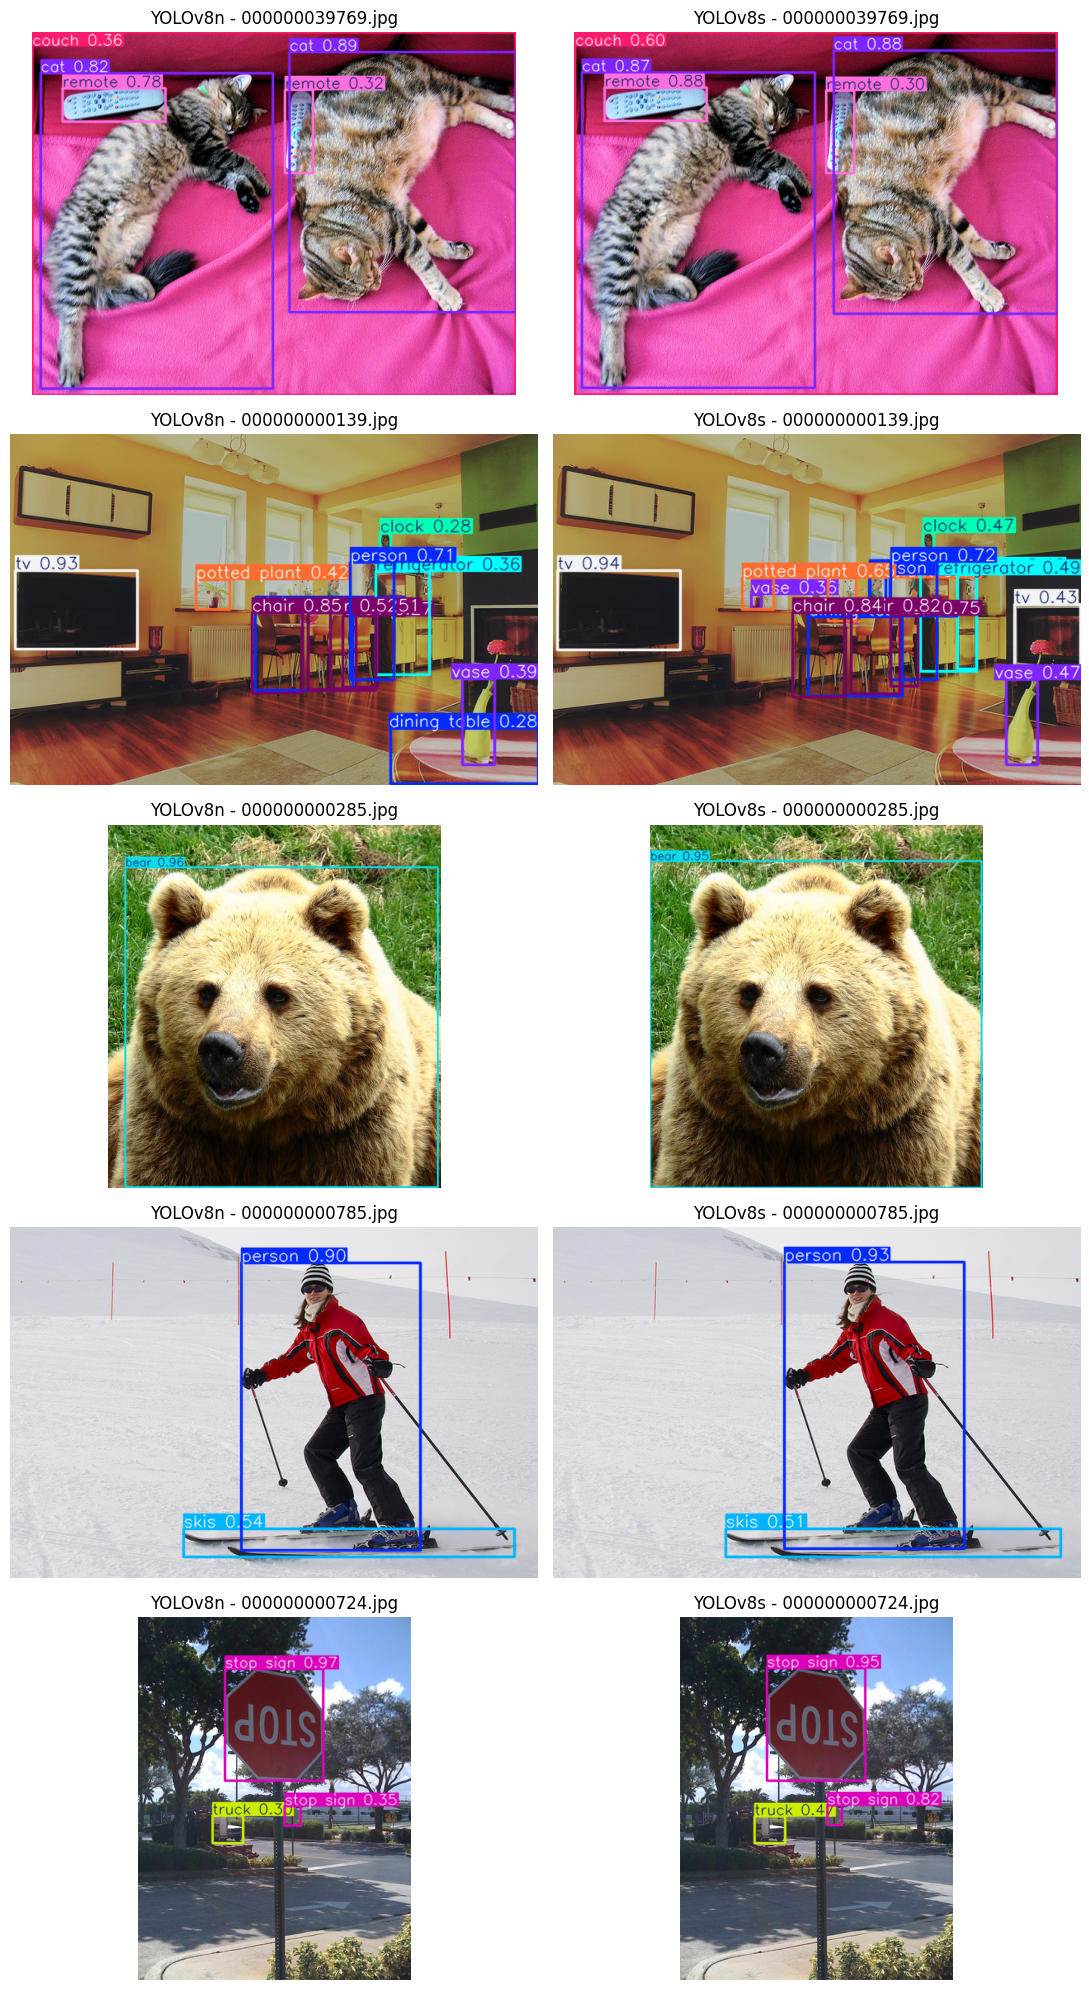

In [3]:
results = {name: [] for name in models}
times = {name: [] for name in models}
for name, m in models.items():
    m.predict(paths[0], verbose=False)                # warm-up run (not timed)
    for p in paths:
        r = m.predict(p, conf=0.25, verbose=False)[0]
        results[name].append(r)
        times[name].append(sum(r.speed.values()))     # preprocess + inference + postprocess (ms)

fig, ax = plt.subplots(len(paths), 2, figsize=(11, 4*len(paths)), squeeze=False)
for row, p in enumerate(paths):
    for col, name in enumerate(models):
        ax[row][col].imshow(cv2.cvtColor(results[name][row].plot(), cv2.COLOR_BGR2RGB))
        ax[row][col].set_title(f"{name} - {os.path.basename(p)}"); ax[row][col].axis("off")
plt.tight_layout(); plt.show()

### Steps 7-8: Evaluation and model comparison
Detections with confidence >= 0.5 are compared with the true objects in each image (`ground_truth`). For each class: **correct** = min(detected, true), **false detections** = detected beyond true, **missed** = true beyond detected (a count-based approximation of TP/FP/FN).
Ground truth is pre-filled for the first COCO image (and `bus.jpg` if the fallback images are used); **view the images above and add the true object counts for the others** to include them in the evaluation.

In [4]:
ground_truth = {"000000039769.jpg": {"cat": 2, "remote": 2, "couch": 1},   # add more: "name.jpg": {"class": count}
                "bus.jpg": {"person": 4, "bus": 1, "stop sign": 1}}

def counts(r, thr=0.5):
    return Counter(r.names[int(c)] for c, s in zip(r.boxes.cls, r.boxes.conf) if s >= thr)

print(f"{'Model':9s}{'Image':18s}{'Correct':>8s}{'False':>7s}{'Missed':>8s}{'Precision':>10s}{'Recall':>8s}")
for name in models:
    for r, p in zip(results[name], paths):
        gt = ground_truth.get(os.path.basename(p))
        if gt is None: continue
        det = counts(r)
        tp = sum(min(det[c], gt[c]) for c in gt)
        fp = sum(det.values()) - tp; fn = sum(gt.values()) - tp
        print(f"{name:9s}{os.path.basename(p):18s}{tp:8d}{fp:7d}{fn:8d}{tp/max(tp+fp,1):10.2f}{tp/max(tp+fn,1):8.2f}")

print(f"\n{'Model':9s}{'Total detections (conf>=0.25)':>32s}{'Avg time / image (ms)':>24s}")
for name in models:
    print(f"{name:9s}{sum(len(r.boxes) for r in results[name]):32d}{np.mean(times[name]):24.1f}")

Model    Image              Correct  False  Missed Precision  Recall
YOLOv8n  000000039769.jpg         3      0       2      1.00    0.60
YOLOv8s  000000039769.jpg         4      0       1      1.00    0.80

Model       Total detections (conf>=0.25)   Avg time / image (ms)
YOLOv8n                                24                   201.2
YOLOv8s                                27                   394.6


### Steps 9-10: Analysis and Observations

**Model comparison:** YOLOv8n is the faster model and suits real-time use on limited hardware; YOLOv8s is slightly slower but generally detects more objects and gives higher confidence scores (see the tables above). The speed/accuracy trade-off is the main criterion when choosing a model.

**Suitability:** YOLOv8 runs in real time, so it is well suited to autonomous driving, surveillance and retail analytics (counting people or products). For industrial inspection of small defects, a model fine-tuned on custom data is needed, because COCO classes do not include such objects.

**Advantages:** high accuracy, one model detects and classifies many objects, works in real time, and pre-trained weights need no training. **Limitations:** small or heavily occluded objects are missed, detections can be wrong under poor lighting or unusual viewpoints, it only knows the 80 COCO classes, and it needs a GPU for high speed.

## Viva Questions

**Q1. Classification vs detection vs segmentation?** Classification gives one label for the whole image. Object detection finds each object with a bounding box and a label. Segmentation labels every pixel (semantic) or every object instance's exact shape (instance).

**Q2. Working of YOLO?** The image is divided into a grid and a single CNN pass predicts, for each cell, bounding boxes, objectness/confidence and class probabilities together. Overlapping boxes are then removed with Non-Maximum Suppression (NMS). Because it looks at the image only once, it is very fast.

**Q3. YOLO vs SSD vs Faster R-CNN?** YOLO: fastest, real-time, good accuracy (video, robotics). SSD: fast, uses multi-scale feature maps, a good balance for mobile devices. Faster R-CNN: two-stage (region proposals, then classification), most accurate especially for small objects but slowest (medical, high-accuracy offline tasks).

**Q4. Bounding box?** A rectangle (x, y, width, height) enclosing an object. It gives the object's location and size, which is what makes detection more useful than plain classification, and is needed for counting, tracking and cropping.

**Q5. Confidence score and IoU?** Confidence is the model's certainty that a box contains an object of that class; low-confidence boxes are discarded using a threshold. IoU = area of overlap / area of union of two boxes; it measures localization accuracy, is used in NMS and to decide if a detection is correct (e.g., IoU >= 0.5).

**Q6. Pre-trained models vs traditional methods?** They learn features automatically from large datasets, are more accurate and robust to lighting, scale and background, need no hand-crafted features, and can be reused or fine-tuned (transfer learning) with little data.

**Q7. Why COCO and Pascal VOC?** They are large, carefully annotated, standard benchmarks (COCO: 80 classes, 330K+ images with boxes and masks), so results of different models can be fairly compared.

**Q8. Five applications?** Autonomous driving, video surveillance, retail analytics, medical imaging (tumour detection), industrial inspection (also smart cities and face detection).

**Q9. Challenges in real-world environments?** Occlusion, small objects, varying lighting and weather, cluttered backgrounds, scale and viewpoint changes, motion blur, class imbalance and real-time speed limits.

**Q10. How to improve?** Use transformer-based detectors (DETR, RT-DETR), larger and augmented datasets, fine-tuning on domain data, self-supervised pre-training, multi-scale and attention mechanisms, model quantization for edge devices, and combining detection with tracking or segmentation.

## Result
Pre-trained YOLOv8n and YOLOv8s models were used to detect objects in MS COCO images. Bounding boxes, labels and confidence scores were displayed, correct/false/missed detections were analysed, and the two models were compared on accuracy and inference speed.